In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import contextily as ctx

from netCDF4 import Dataset
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS, Transformer

from scipy.interpolate import interp1d
from scipy.stats import linregress

from pymannkendall import original_test as mk_test

from utils import process_events


pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
hydroDir = "/eos/jeodpp/data/projects/CLIMEX/CFRisks/CFRisks_data/"

In [3]:
NUTS3 = gpd.read_file(f"{hydroDir}/NUTS3/NUTS3_modified.shp")
NutVector = NUTS3['NUTS_ID'].tolist()

In [4]:
Hanze_flood = pd.read_csv(f"{hydroDir}/HANZE/HANZE_events.csv")
Hanze_flood_1980 = Hanze_flood[Hanze_flood['Year'] > 1980]
Hanze_flood_1980 = Hanze_flood_1980[Hanze_flood_1980['Type'] != "Coastal"]
list_of_word_vectors = [regions.split(';') for regions in Hanze_flood['Regions affected (v2021)']]

In [5]:
len(Hanze_flood_1980)

1349

In [6]:
fl_events = pd.read_csv(f"{hydroDir}/hazard_data/fl_nuts3_v1.csv", index_col=0)
fl_events['enddate'] = pd.to_datetime(fl_events['enddate'])
fl_events['stardate'] = fl_events['enddate'] - pd.to_timedelta(fl_events['duration'], unit='D')

In [7]:
hw_events = pd.read_csv(f"{hydroDir}/hazard_data/hw_nuts3_v1.csv")
hw_events['stardate'] = pd.to_datetime(hw_events['stardate'], format="%d/%m/%Y %H:%M", errors='coerce')
hw_events['enddate'] = pd.to_datetime(hw_events['enddate'], format="%d/%m/%Y %H:%M", errors='coerce')


In [8]:

grouped_events = hw_events.groupby('nuts_id').size().reset_index(name='heatwaves')
grouped_events.rename(columns={'nuts_id': 'NUTS_ID'}, inplace=True)


In [9]:
NUTS3_2021 = gpd.read_file(f"{hydroDir}/NUTS3/Regions_v2021_simplified.shp")

heat_plot = NUTS3_2021.merge(
    grouped_events,
    left_on='Code',
    right_on='NUTS_ID',
    how='left'
)

# Replace 0 with NaN for transparency in the plot
heat_plot.loc[heat_plot['heatwaves'] == 0, 'heatwaves'] = np.nan

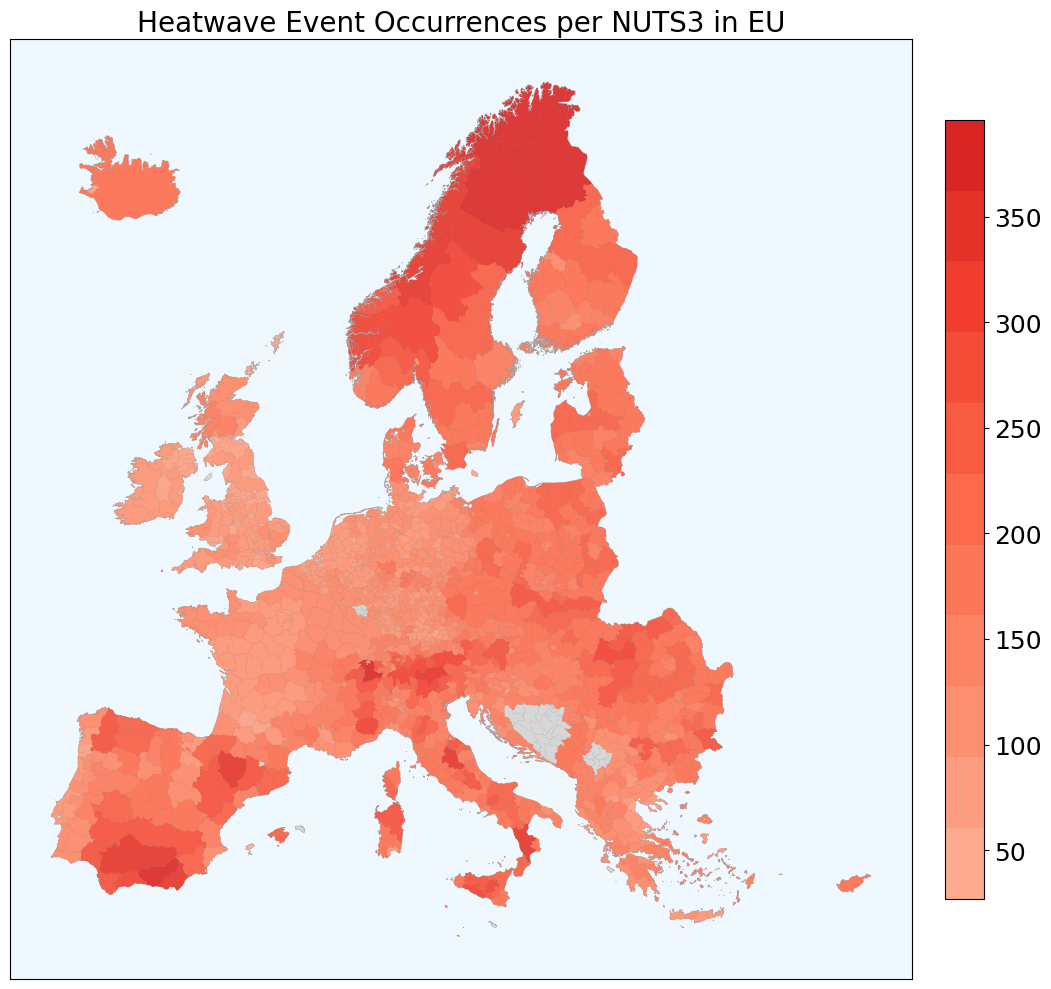

In [10]:

# Define a light red colormap
paletf = plt.cm.Reds(np.linspace(0.3, 0.7, 11))  # Use Reds for light red shades
cmap = mcolors.ListedColormap(paletf)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 10))

# Base map with subtle borders
NUTS3_2021.plot(ax=ax, facecolor='white', edgecolor='darkgrey', linewidth=0.5)

# Plot the heatwave occurrences without borders
heat_plot.plot(
    ax=ax,
    column='heatwaves',
    cmap=cmap,
    alpha=0.9,
    edgecolor='none',
    missing_kwds={'color': 'lightgrey'}
)

# Add a color bar
vmin = heat_plot['heatwaves'].min(skipna=True)
vmax = heat_plot['heatwaves'].max(skipna=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array(heat_plot['heatwaves'])

cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
#cbar.set_label("Number of Heatwave Events", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# Aesthetics
ax.set_facecolor('aliceblue')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title("Heatwave Event Occurrences per NUTS3 in EU", fontsize=20)

plt.tight_layout()
plt.savefig("../plots/heatwave_events.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# --- Definition of temporal windows ---
# Informed window
IHW = 14

# Three tested windows
short, medium, long = 14, 28, 56

windows = ["informed"]


list_POTx_large = []

for w in windows:
    wheat = IHW
    df_POTx_large_w = pd.DataFrame()

    for NUTl in NutVector:
        # Subset events per region
        High_events = fl_events[fl_events["NUT"] == NUTl]
        if not High_events.empty:
            HW_events = hw_events[hw_events["nuts_id"] == NUTl]

            # Match Hanze rows for this NUT
            matches = [NUTl in vec for vec in list_of_word_vectors]
            tm = [i for i, val in enumerate(matches) if val]
            Hanze_Nut = Hanze_flood.iloc[tm]
            Hanze_Nut = Hanze_Nut[Hanze_Nut["Year"] > 1980].copy()
            Hanze_Nut["eid"] = Hanze_Nut["ID"]

            df_POTx_keep = pd.DataFrame()

            for e, eid in enumerate(Hanze_Nut["ID"]):
                POTx_keep = process_events(
                    events_df=HW_events,
                    reference_df=Hanze_Nut,
                    event_idx=e,
                    window=wheat,
                    nut_id=NUTl,
                    haz="heat",
                )
                df_POTx_keep = pd.concat([df_POTx_keep, POTx_keep], ignore_index=True)

            # Append region-level results
            df_POTx_large_w = pd.concat([df_POTx_large_w, df_POTx_keep], ignore_index=True)

    # Add NEID column per hazard
    for df in [df_POTx_large_w]:
        df["NEID"] = df["eventID"].astype(str) + df["NUTID"]

    list_POTx_large.append(df_POTx_large_w)


In [12]:
list_POTx_large[0]

,nuts_id,stardate,enddate,intensity,dtime1,dtime2,NUTID,eventStart,eventEnd,eventID,NEID
0,ES512,1982-01-30,1982-02-02,3,-13,-13,ES512,1982-02-16,1982-02-16,2678,2678ES512
1,ES512,1987-09-12,1987-09-24,12,-3,-3,ES512,1987-09-28,1987-10-06,1328,1328ES512
2,ES512,2014-11-21,2014-11-25,4,-4,-4,ES512,2014-11-30,2014-11-30,2312,2312ES512
3,BG412,2007-05-12,2007-05-17,3,-4,-4,BG412,2007-05-22,2007-06-06,50,50BG412
4,BG341,2015-01-19,2015-01-24,5,-7,-7,BG341,2015-02-01,2015-02-04,57,57BG341
...,...,...,...,...,...,...,...,...,...,...,...
408,RS212,2010-06-11,2010-06-17,5,-5,-5,RS212,2010-06-23,2010-07-02,2284,2284RS212
409,RS217,2016-02-15,2016-02-20,4,-14,-14,RS217,2016-03-06,2016-03-07,2292,2292RS217
410,RS214,2016-02-15,2016-02-20,4,-14,-14,RS214,2016-03-06,2016-03-07,2292,2292RS214
411,NO0A3,1993-01-01,1993-01-04,3,-3,-3,NO0A3,1993-01-08,1993-01-18,2373,2373NO0A3


In [13]:
hw_match_results = list_POTx_large[0]

In [14]:
len(hw_match_results), len(hw_events)

(413, 239438)

In [15]:
hw_match_results['time'] = pd.to_datetime(hw_match_results['stardate'])
hw_events['time'] = pd.to_datetime(hw_events['stardate'])

hw_match_results = hw_match_results[hw_match_results['time'].dt.month.between(5,10)]
hw_events = hw_events[hw_events['time'].dt.month.between(5,10)]


In [16]:
len(hw_match_results), len(hw_events)

(279, 117957)

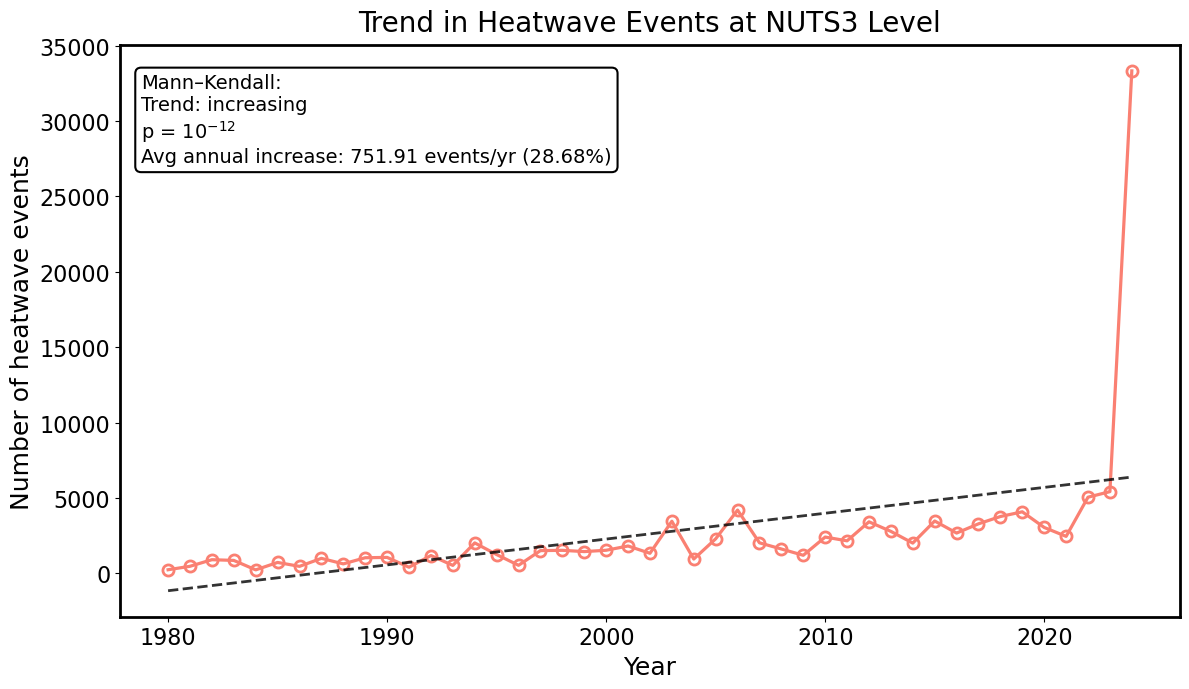

In [17]:


# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

# Ensure stardate is datetime
hw_events["stardate"] = pd.to_datetime(hw_events["stardate"])

# Extract year
hw_events["year"] = hw_events["stardate"].dt.year

# Count events per year
events_per_year = (
    hw_events.groupby("year")
    .size()
    .reset_index(name="n_events")
)

# Sorted by year (important for trend calculations)
events_per_year = events_per_year.sort_values("year")

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Compute differences to get average annual increase
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent relative to mean number of yearly events
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall monotonic trend test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = "increasing" if mk_result.trend == "increasing" else \
            "decreasing" if mk_result.trend == "decreasing" else "no trend"

def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FITTED LINE (simple linear regression)
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, r_value, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years,
    counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2.0,
    markeredgecolor="salmon", 
    linewidth=2.3,
    color="salmon",
)

# Fitted trendline (black dashed)
plt.plot(
    years,
    trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8,
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of heatwave events", fontsize=18)
plt.title("Trend in Heatwave Events at NUTS3 Level", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker axis spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()



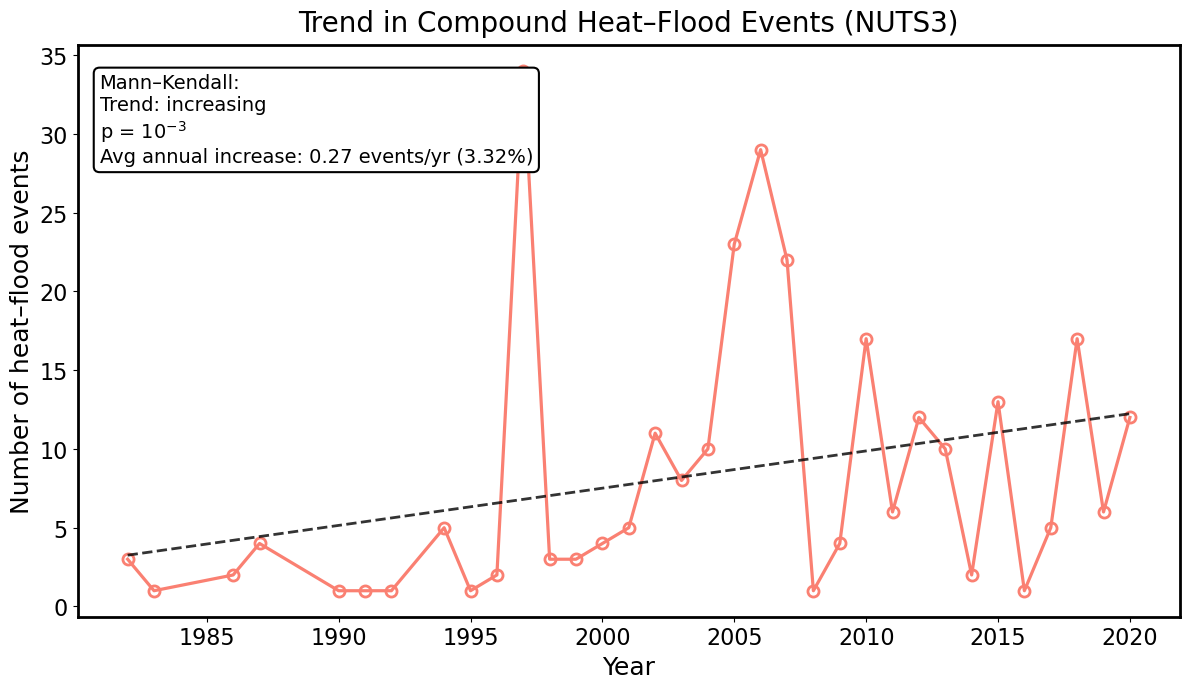

In [18]:


# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

df = hw_match_results.copy()

# Ensure stardate is datetime
df["stardate"] = pd.to_datetime(df["stardate"])

# Extract year
df["year"] = df["stardate"].dt.year

# Count events per year
events_per_year = (
    df.groupby("year")
      .size()
      .reset_index(name="n_events")
      .sort_values("year")
)

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Average annual increase (simple diff)
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent increase relative to mean
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = (
    "increasing" if mk_result.trend == "increasing"
    else "decreasing" if mk_result.trend == "decreasing"
    else "no trend"
)

# p-value as 10^{-x}
def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FIT LINEAR TREND
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, rvalue, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years, counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2,
    markeredgecolor="salmon",
    linewidth=2.3,
    color="salmon"
)

# Trendline
plt.plot(
    years, trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of heat–flood events", fontsize=18)
plt.title("Trend in Compound Heat–Flood Events (NUTS3)", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()


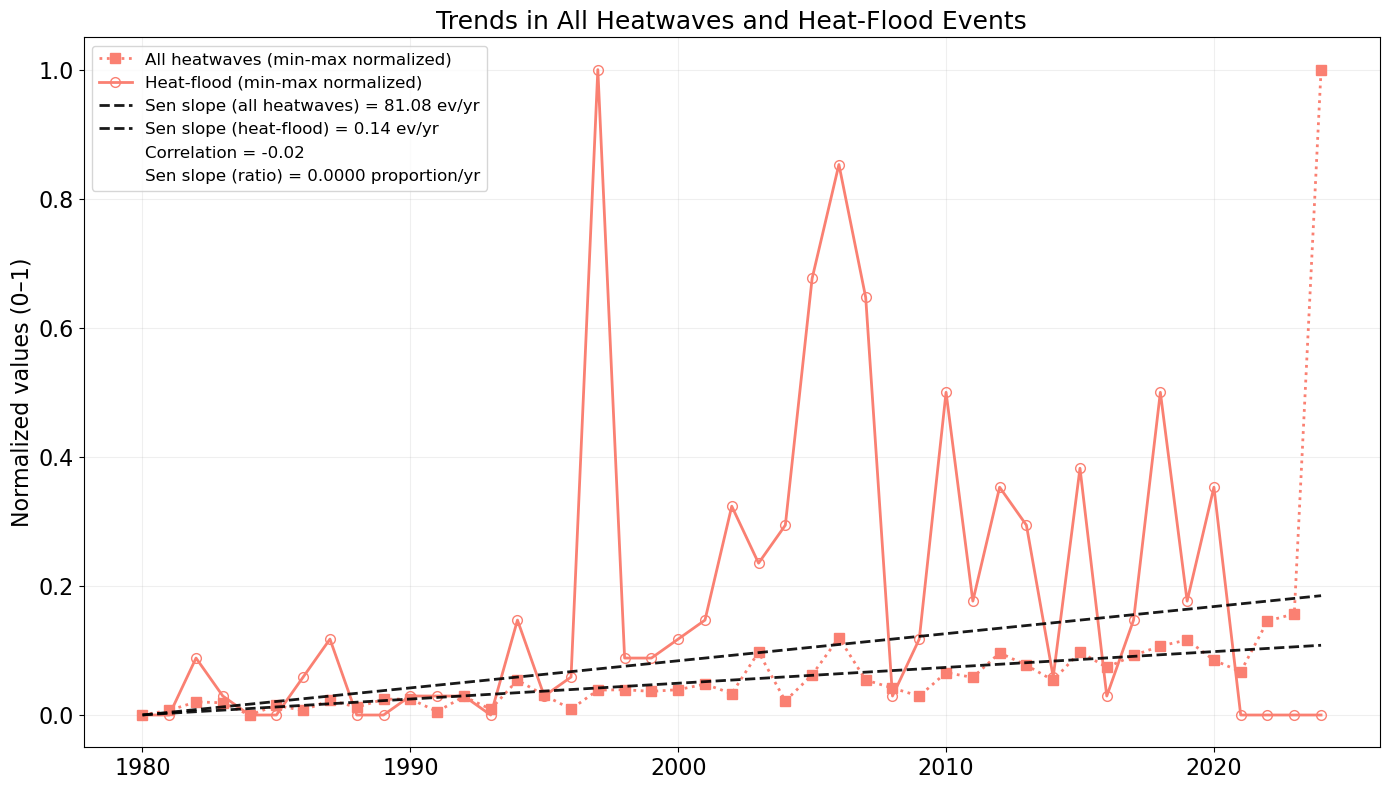

Heatwaves MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=4.6425085997725546e-12, z=6.916100070949491, Tau=0.7151515151515152, s=708.0, var_s=10450.0, slope=81.08333333333334, intercept=-247.83333333333348)
Compound MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=0.013042947918726622, z=2.4825944672042657, Tau=0.2545454545454545, s=252.0, var_s=10222.0, slope=0.14285714285714285, intercept=-0.1428571428571428)
Proportion MK Test: Mann_Kendall_Test(trend='no trend', h=False, p=0.34383977191252524, z=0.9466056341177724, Tau=0.09797979797979799, s=97.0, var_s=10285.0, slope=1.5847201169744517e-05, intercept=0.0019635003025893203)
Correlation between Heatwaves and Compound Events: -0.02


In [20]:

df_hw = hw_events.copy()
df_compound = hw_match_results.copy()

df_hw["year"] = pd.to_datetime(df_hw["stardate"]).dt.year
df_compound["year"] = pd.to_datetime(df_compound["stardate"]).dt.year

hw_yearly = df_hw.groupby("year").size().reset_index(name="heat_count")
compound_yearly = df_compound.groupby("year").size().reset_index(name="compound_count")

df_years = pd.merge(hw_yearly, compound_yearly, on="year", how="left").fillna(0)
df_years = df_years.sort_values("year").reset_index(drop=True)

years = df_years["year"].values
D = df_years["heat_count"].values.astype(float)
C = df_years["compound_count"].values.astype(float)

# Mann-Kendall + Sen slope (original counts)
mk_D = mk_test(D)
mk_C = mk_test(C)

slope_D = mk_D.slope   # events per year (Sen)
slope_C = mk_C.slope

# Calculate proportions and perform MK test on proportions
mask = D > 0
p = (C[mask] / D[mask]).astype(float)
years_p = years[mask]

mk_p = mk_test(p)
slope_p = mk_p.slope

# Correlation between D and C
correlation = np.corrcoef(D, C)[0, 1]

# MIN-MAX normalization for plotting
def minmax_scale(x):
    x_min, x_max = x.min(), x.max()
    if x_max == x_min:
        return np.zeros_like(x), x_min, x_max
    return (x - x_min) / (x_max - x_min), x_min, x_max

D_norm, D_min, D_max = minmax_scale(D)
C_norm, C_min, C_max = minmax_scale(C)

# Rescale Sen slopes to normalized units for plotting trendlines
slope_D_norm = slope_D / (D_max - D_min) if (D_max - D_min) != 0 else 0.0
slope_C_norm = slope_C / (C_max - C_min) if (C_max - C_min) != 0 else 0.0

trend_D_norm = slope_D_norm * (years - years.min()) + D_norm[0]
trend_C_norm = slope_C_norm * (years - years.min()) + C_norm[0]

# Plot
plt.figure(figsize=(14, 8))

plt.plot(years, D_norm, marker="s", markersize=7, label="All heatwaves (min-max normalized)", linewidth=2,
         markerfacecolor="salmon", markeredgecolor="salmon", linestyle=":", color="salmon")
plt.plot(years, C_norm, marker="o", markersize=7, label="Heat-flood (min-max normalized)",
         linewidth=2, markerfacecolor="none", markeredgecolor="salmon", color="salmon")

# Trendlines (black dashed)
plt.plot(years, trend_D_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (all heatwaves) = {slope_D:.2f} ev/yr")
plt.plot(years, trend_C_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (heat-flood) = {slope_C:.2f} ev/yr")

# Add correlation and Sen slope of ratio to the legend
plt.plot([], [], ' ', label=f"Correlation = {correlation:.2f}")
plt.plot([], [], ' ', label=f"Sen slope (ratio) = {slope_p:.4f} proportion/yr")

plt.xlabel("", fontsize=16)
plt.ylabel("Normalized values (0–1)", fontsize=16)
plt.title("Trends in All Heatwaves and Heat-Flood Events", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(axis='both', labelsize=16)

plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()

# Print analysis results
print(f"Heatwaves MK Test: {mk_D}")
print(f"Compound MK Test: {mk_C}")
print(f"Proportion MK Test: {mk_p}")
print(f"Correlation between Heatwaves and Compound Events: {correlation:.2f}")

